In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
df = pd.read_csv('OnlineRetail.csv', encoding='ISO-8859-1')

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
# Understand the structure (shape dtypes and feature types)
# Shape: rows and columns
print(df.shape)

#Data types of each column
df.info()

(541909, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


## Dataset Description

This dataset contains transaction-level records of purchases from a UK-based online retail store, covering transactions from December 2010 onward. Each row represents a single product line-item within a customer invoice — meaning one invoice (order) can span multiple rows if a customer purchased multiple different products in the same transaction.

**Key details:**
- **Rows:** 541,909
- **Columns:** 8
- **Granularity:** One row = one product purchased within a single invoice

**Columns:**
- `InvoiceNo` — Unique identifier for each invoice/order (invoices starting with "C" indicate cancellations)
- `StockCode` — Unique identifier for each product
- `Description` — Product name/description
- `Quantity` — Number of units purchased in that line-item
- `InvoiceDate` — Date and time the transaction occurred
- `UnitPrice` — Price per unit (in GBP, £)
- `CustomerID` — Unique identifier for the customer who made the purchase
- `Country` — Country the customer ordered from

**Numerical features:** Quantity, UnitPrice
**Categorical features:** InvoiceNo, StockCode, Description, CustomerID, Country
**Possible primary key:** No single column uniquely identifies a row; the combination of `InvoiceNo` + `StockCode` is the likely row-level identifier (to be verified during duplicate checks)

In [4]:
# Identifycolumns with missing values and count them  
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
# Missing values as a percentage
(df.isnull().sum() / len(df)) * 100

InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
dtype: float64

### Handling Missing Values: Description

**Issue:** The `Description` column had 1,454 missing values (0.27% of the dataset).

**Action Taken:** Dropped the rows where `Description` was missing.

**Reasoning:** `Description` is a text field representing the product name, so missing 
values cannot be meaningfully imputed (there is no numerical average or mode that 
logically fills in a missing product name). Since the missing values represent a 
very small fraction of the dataset (0.27%), removing these rows has a negligible 
impact on the overall dataset size and analysis, while keeping the data clean and 
avoiding placeholder values like "Unknown" that could distort product-level analysis.

In [6]:
# Drop rows where Description is missing
before_rows = df.shape[0]
df = df.dropna(subset=['Description'])
after_rows = df.shape[0]

print(f"Rows before: {before_rows}")
print(f"Rows after: {after_rows}")
print(f"Rows dropped: {before_rows - after_rows}")

Rows before: 541909
Rows after: 540455
Rows dropped: 1454


### Handling Missing Values: CustomerID

**Issue:** The `CustomerID` column had 135,080 missing values (24.9% of the dataset).

**Investigation:** Checked whether missing CustomerID was linked to cancelled orders 
(InvoiceNo starting with "C"). Only 383 of the 135,080 missing rows were cancellations, 
meaning the vast majority (133,243 rows) were normal completed transactions — most 
likely guest checkouts where no customer account was linked.

**Action Taken:** Kept all rows and filled missing `CustomerID` values with `-1` as a 
placeholder flag, rather than dropping the rows.

**Reasoning:** With ~25% of the dataset missing this value, dropping these rows would 
remove a large volume of valid transaction data (Quantity, UnitPrice, Country) that is 
still useful for revenue and product-level analysis, which do not depend on knowing the 
customer's identity. Filling with `-1` (a value no real CustomerID can have) preserves 
these rows while clearly flagging them as "unknown customer," so any customer-level 
analysis (e.g., average spend per customer) can filter these out explicitly later.

In [7]:
# Check if missing CustomerID rows are linked to cancelled invoices
df[df['CustomerID'].isnull()]['InvoiceNo'].astype(str).str.startswith('C').value_counts()

InvoiceNo
False    133243
True        383
Name: count, dtype: int64

In [8]:
# Flag missing CustomerID with a placeholder value (-1) instead of dropping rows
# Rationale: ~24.9% of rows are missing CustomerID, and investigation showed these 
# are mostly normal completed transactions (not cancellations), likely guest checkouts.
# Dropping this many rows would remove valid Quantity/UnitPrice/Country data needed 
# for revenue and product-level analysis. Instead, we fill with -1 (a value that 
# cannot be a real CustomerID) to flag these as "unknown customer" while preserving 
# the rows and keeping the column numeric.

df['CustomerID'] = df['CustomerID'].fillna(-1)

# Confirm no missing values remain
print(df['CustomerID'].isnull().sum())
print(df['CustomerID'].value_counts().head())

0
CustomerID
-1.0        133626
 17841.0      7983
 14911.0      5903
 14096.0      5128
 12748.0      4642
Name: count, dtype: int64


## Duplicate Records

Before moving to standardization, we check the dataset for duplicate rows — cases 
where an entire transaction line (every column: InvoiceNo, StockCode, Description, 
Quantity, InvoiceDate, UnitPrice, CustomerID, Country) is repeated exactly. 

Duplicate rows can distort analysis by inflating totals — for example, overstating 
quantities sold or revenue generated — so it's important to identify and remove them 
before drawing any conclusions from the data.

In [9]:
# Check for exact duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 5268


In [10]:
# Remove exact duplicate rows
before_rows = df.shape[0]
df = df.drop_duplicates()
after_rows = df.shape[0]

print(f"Rows before: {before_rows}")
print(f"Rows after: {after_rows}")
print(f"Duplicate rows removed: {before_rows - after_rows}")

Rows before: 540455
Rows after: 535187
Duplicate rows removed: 5268


### Standardization: Date Format

**Issue:** `InvoiceDate` was stored as text (object type), e.g., "12/1/2010 8:26", 
rather than an actual date/time value — meaning date-based operations 
(sorting, filtering, extracting month/day) weren't possible.

**Action Taken:** Converted `InvoiceDate` to a proper `datetime64` type using 
`pd.to_datetime()`, explicitly specifying the format as month/day/year 
(`%m/%d/%Y %H:%M`) to match the source data and avoid misinterpretation of 
ambiguous dates.

**Result:** `InvoiceDate` is now a true datetime column, enabling time-based 
analysis such as monthly sales trends or day-of-week patterns.

In [11]:
# Convert InvoiceDate from text to actual datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%m/%d/%Y %H:%M')

#Confrim the conversion worked
print(df['InvoiceDate'].dtype)
df['InvoiceDate'].head()

datetime64[ns]


0   2010-12-01 08:26:00
1   2010-12-01 08:26:00
2   2010-12-01 08:26:00
3   2010-12-01 08:26:00
4   2010-12-01 08:26:00
Name: InvoiceDate, dtype: datetime64[ns]

In [12]:
# Text formatting for description and country
# Check unique values for country (small enough to eyeball directly)
df['Country'].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Bahrain', 'Greece', 'Hong Kong', 'Singapore',
       'Lebanon', 'United Arab Emirates', 'Saudi Arabia',
       'Czech Republic', 'Canada', 'Unspecified', 'Brazil', 'USA',
       'European Community', 'Malta', 'RSA'], dtype=object)

In [13]:
# Check a sample of description values for casing or spacing issues
df['Description'].unique()[:20]

array(['WHITE HANGING HEART T-LIGHT HOLDER', 'WHITE METAL LANTERN',
       'CREAM CUPID HEARTS COAT HANGER',
       'KNITTED UNION FLAG HOT WATER BOTTLE',
       'RED WOOLLY HOTTIE WHITE HEART.', 'SET 7 BABUSHKA NESTING BOXES',
       'GLASS STAR FROSTED T-LIGHT HOLDER', 'HAND WARMER UNION JACK',
       'HAND WARMER RED POLKA DOT', 'ASSORTED COLOUR BIRD ORNAMENT',
       "POPPY'S PLAYHOUSE BEDROOM ", "POPPY'S PLAYHOUSE KITCHEN",
       'FELTCRAFT PRINCESS CHARLOTTE DOLL', 'IVORY KNITTED MUG COSY ',
       'BOX OF 6 ASSORTED COLOUR TEASPOONS',
       'BOX OF VINTAGE JIGSAW BLOCKS ', 'BOX OF VINTAGE ALPHABET BLOCKS',
       'HOME BUILDING BLOCK WORD', 'LOVE BUILDING BLOCK WORD',
       'RECIPE BOX WITH METAL HEART'], dtype=object)

In [14]:
# Strip leading/trailing whitespace from text columns
df['Description'] = df['Description'].str.strip()
df['Country'] = df['Country'].str.strip()

# Confirm no more trailing/leading spaces
print(df['Description'].str.startswith(' ').sum(), df['Description'].str.endswith(' ').sum())

# Why .str.strip(): it removes any leading or trailing whitespace character(s) without touching the actual text content or casing. The check afterward confirms zero rows still start or end with a space.

0 0


### Standardization: Text Formatting

**Issue:** 
- `Country` values were already consistently formatted (proper case), so no casing 
  changes were needed.
- `Description` values were consistently uppercase, but several entries had 
  trailing/leading whitespace (e.g., "BOX OF VINTAGE JIGSAW BLOCKS "), which could 
  cause pandas to treat identical products as distinct categories during grouping 
  or counting.

**Action Taken:** Stripped leading and trailing whitespace from `Description` and 
`Country` using `.str.strip()`.

**Reasoning:** Whitespace differences are invisible to the eye but functionally 
significant to pandas — two otherwise identical strings with different whitespace 
are treated as separate categories. Stripping ensures accurate grouping and counting 
for product- and country-level analysis.

### Standardization: Column Names

**Issue:** Column names were in CamelCase (e.g., `InvoiceNo`, `UnitPrice`, `CustomerID`), 
which is inconsistent with standard Python/pandas naming conventions.

**Action Taken:** Converted all column names to lowercase snake_case 
(e.g., `InvoiceNo` → `invoice_no`, `UnitPrice` → `unit_price`).

**Reasoning:** snake_case is the standard naming convention in Python and pandas, 
reducing the risk of case-sensitivity errors when referencing columns and improving 
readability and consistency across the codebase.

In [15]:
# Standardize column names to snake_case
df.columns = df.columns.str.lower()
df.rename(columns={
    'invoiceno': 'invoice_no',
    'stockcode': 'stock_code',
    'invoicedate': 'invoice_date',
    'unitprice': 'unit_price',
    'customerid': 'customer_id'
}, inplace=True)

# Confirm the new column names
print(df.columns.tolist())

['invoice_no', 'stock_code', 'description', 'quantity', 'invoice_date', 'unit_price', 'customer_id', 'country']


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 535187 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   invoice_no    535187 non-null  object        
 1   stock_code    535187 non-null  object        
 2   description   535187 non-null  object        
 3   quantity      535187 non-null  int64         
 4   invoice_date  535187 non-null  datetime64[ns]
 5   unit_price    535187 non-null  float64       
 6   customer_id   535187 non-null  float64       
 7   country       535187 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 36.7+ MB


In [17]:
# Convert customer_id to integer now that missing values are filled
df['customer_id'] = df['customer_id'].astype('int64')

# Confirm
print(df['customer_id'].dtype)
df['customer_id'].head()

int64


0    17850
1    17850
2    17850
3    17850
4    17850
Name: customer_id, dtype: int64

### Standardization: Data Types

**Issue:** `customer_id` was stored as `float64` (e.g., 17850.0) rather than an 
integer, a side effect of previously containing missing values (NaN forces a column 
to float in pandas). `invoice_date` had already been corrected to `datetime64` in 
the date formatting step.

**Action Taken:** Converted `customer_id` to `int64` now that missing values have 
been filled with the placeholder -1.

**Reasoning:** Customer IDs are identifiers, not continuous numeric values, so they 
should not carry decimal precision. Converting to integer improves clarity and is 
more appropriate for an ID field.

In [18]:
# Data Validation
# Check for negative or zero values in quantity and unit_price
print("Negative quantity:", (df['quantity'] < 0).sum())
print("Zero quantity:", (df['quantity'] == 0).sum())
print("Negative unit_price:", (df['unit_price'] < 0).sum())
print("Zero unit_price:", (df['unit_price'] == 0).sum())

Negative quantity: 9725
Zero quantity: 0
Negative unit_price: 2
Zero unit_price: 1056


In [19]:
# Whether negative quantity rows align with cancelled invoices (invoice_no starting with "C")
# 1. Negative quantity vs cancelled invoices
neg_qty = df[df['quantity'] < 0]
print(neg_qty['invoice_no'].astype(str).str.startswith('C').value_counts())


invoice_no
True     9251
False     474
Name: count, dtype: int64


In [20]:
# 2. The 2 negative unit_price rows
df[df['unit_price'] < 0]

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,-1,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,-1,United Kingdom


In [21]:
# 3. Sample of zero unit_price rows
df[df['unit_price'] == 0].head(10)

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
6391,536941,22734,amazon,20,2010-12-03 12:08:00,0.0,-1,United Kingdom
6392,536942,22139,amazon,15,2010-12-03 12:08:00,0.0,-1,United Kingdom
7313,537032,21275,?,-30,2010-12-03 16:50:00,0.0,-1,United Kingdom
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647,Germany
13217,537425,84968F,check,-20,2010-12-06 15:35:00,0.0,-1,United Kingdom
13218,537426,84968E,check,-35,2010-12-06 15:36:00,0.0,-1,United Kingdom
13264,537432,35833G,damages,-43,2010-12-06 16:10:00,0.0,-1,United Kingdom
14335,537534,85064,CREAM SWEETHEART LETTER RACK,1,2010-12-07 11:48:00,0.0,-1,United Kingdom
14336,537534,84832,ZINC WILLIE WINKIE CANDLE STICK,1,2010-12-07 11:48:00,0.0,-1,United Kingdom
14337,537534,84692,BOX OF 24 COCKTAIL PARASOLS,2,2010-12-07 11:48:00,0.0,-1,United Kingdom


In [22]:
# The 474 negative quantity rows that are NOT cancellations
non_cancel_neg = df[(df['quantity'] < 0) & (~df['invoice_no'].astype(str).str.startswith('C'))]
non_cancel_neg.head(15)

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
7313,537032,21275,?,-30,2010-12-03 16:50:00,0.0,-1,United Kingdom
13217,537425,84968F,check,-20,2010-12-06 15:35:00,0.0,-1,United Kingdom
13218,537426,84968E,check,-35,2010-12-06 15:36:00,0.0,-1,United Kingdom
13264,537432,35833G,damages,-43,2010-12-06 16:10:00,0.0,-1,United Kingdom
21338,538072,22423,faulty,-13,2010-12-09 14:10:00,0.0,-1,United Kingdom
21518,538090,20956,?,-723,2010-12-09 14:48:00,0.0,-1,United Kingdom
22296,538161,46000S,Dotcom sales,-100,2010-12-09 17:25:00,0.0,-1,United Kingdom
22297,538162,46000M,Dotcom sales,-100,2010-12-09 17:25:00,0.0,-1,United Kingdom
42564,540010,22501,reverse 21/5/10 adjustment,-100,2011-01-04 11:13:00,0.0,-1,United Kingdom
42566,540012,22502,reverse 21/5/10 adjustment,-100,2011-01-04 11:14:00,0.0,-1,United Kingdom


In [23]:
# Split zero-price rows: internal adjustments (no customer) vs real transactions (has customer)
zero_price = df[df['unit_price'] == 0]
print(zero_price['customer_id'].apply(lambda x: 'No customer (-1)' if x == -1 else 'Has real customer').value_counts())

customer_id
No customer (-1)     1016
Has real customer      40
Name: count, dtype: int64


### Data Validation: Investigating Negative & Zero Values

**What we're checking:** Beyond missing values and duplicates, we need to check 
whether the actual *values* in the data make logical sense. A row can be complete 
and unique, but still represent something illogical (like a negative price) or 
something that isn't a real customer transaction at all.

**What we found:**

1. **Negative quantity (9,725 rows):** 9,251 of these belong to invoices starting 
   with "C" — the standard code for a **cancelled order**. This is a legitimate 
   business event (a customer return), not an error, so these rows are meaningful 
   and should be kept.

2. **Negative quantity, NOT cancellations (474 rows):** These all have `unit_price = 0` 
   and `customer_id = -1` (no real customer). Looking at the `description` field, 
   these are entries like "damages", "check", "mouldy, thrown away", "faulty" — 
   these are **internal warehouse/inventory adjustment notes**, not customer purchases. 
   Someone on the operations side was recording stock write-offs or corrections, not 
   selling a product.

3. **Negative unit_price (2 rows):** Both are labeled "Adjust bad debt" with no real 
   customer — an internal **accounting entry**, not a sale.

4. **Zero unit_price (1,056 rows):** Split into two groups:
   - **1,016 rows** have no real customer (`customer_id = -1`) — same pattern as 
     above, internal inventory notes, not real transactions.
   - **40 rows** have a real customer ID — these need a closer look, since they 
     could be legitimate free promotional items given to actual customers.

**Why this matters:** Since our dataset is meant to represent *customer transactions*, 
rows that are actually internal inventory/accounting notes (no real customer, no real 
price, non-product descriptions) don't belong here — including them would distort 
any analysis of sales, revenue, or customer behavior. Genuine returns (cancellations) 
are different — they represent real customer activity and should stay.

In [24]:
# The 40 zero-price rows with a real customer
df[(df['unit_price'] == 0) & (df['customer_id'] != -1)]

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647,Germany
33576,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,2010-12-16 14:36:00,0.0,16560,United Kingdom
40089,539722,22423,REGENCY CAKESTAND 3 TIER,10,2010-12-21 13:45:00,0.0,14911,EIRE
47068,540372,22090,PAPER BUNTING RETROSPOT,24,2011-01-06 16:41:00,0.0,13081,United Kingdom
47070,540372,22553,PLASTERS IN TIN SKULLS,24,2011-01-06 16:41:00,0.0,13081,United Kingdom
56674,541109,22168,ORGANISER WOOD ANTIQUE WHITE,1,2011-01-13 15:10:00,0.0,15107,United Kingdom
86789,543599,84535B,FAIRY CAKES NOTEBOOK A6 SIZE,16,2011-02-10 13:08:00,0.0,17560,United Kingdom
130188,547417,22062,CERAMIC BOWL WITH LOVE HEART DESIGN,36,2011-03-23 10:25:00,0.0,13239,United Kingdom
139453,548318,22055,MINI CAKE STAND HANGING STRAWBERY,5,2011-03-30 12:45:00,0.0,13113,United Kingdom
145208,548871,22162,HEART GARLAND RUSTIC PADDED,2,2011-04-04 14:42:00,0.0,14410,United Kingdom


### Data Validation: The 40 Zero-Price Rows with Real Customers

**What we found:** Unlike the 1,016 zero-price rows with no customer (internal 
inventory notes), these 40 rows have a real `customer_id` and mostly show normal 
product descriptions and quantities — consistent with **free/promotional items** 
given to actual customers as part of a real order (e.g., a gift or goodwill item).

**The exception:** 6 of these 40 rows have `stock_code = "M"` and 
`description = "Manual"` — this is a system code for a manually-entered adjustment, 
not a real product a customer purchased.

**Decision:** Keep the 34 rows that represent real free/promotional items tied to a 
genuine customer and order. Remove the 6 "Manual" adjustment rows, consistent with 
our treatment of other internal, non-product entries.

In [25]:
# --- Data Validation: Handling invalid/non-transaction rows ---

before_rows = df.shape[0]

# 1. Remove the 2 "Adjust bad debt" rows (negative unit_price, internal accounting)
df = df[df['description'] != 'Adjust bad debt']

# 2. Remove the 474 negative-quantity rows that are NOT cancellations 
#    (these are internal inventory adjustments: damages, checks, etc.)
df = df[~((df['quantity'] < 0) & (~df['invoice_no'].astype(str).str.startswith('C')))]

# 3. Remove zero-price rows with no real customer (internal inventory notes)
df = df[~((df['unit_price'] == 0) & (df['customer_id'] == -1))]

# 4. Remove zero-price rows tied to "Manual" entries (not real products)
df = df[~((df['unit_price'] == 0) & (df['description'] == 'Manual'))]

after_rows = df.shape[0]

print(f"Rows before: {before_rows}")
print(f"Rows after: {after_rows}")
print(f"Rows removed: {before_rows - after_rows}")

Rows before: 535187
Rows after: 534162
Rows removed: 1025


### Data Validation: Removing Invalid / Non-Transaction Rows

**Issue:** Several rows in the dataset did not represent genuine customer 
transactions, despite passing earlier checks (no missing values, not duplicates):

- 2 rows were internal accounting entries ("Adjust bad debt") with a large negative 
  unit_price, unrelated to any actual product sale.
- 474 rows had negative quantity but were not cancelled orders — investigation 
  showed these were internal inventory adjustments (e.g., "damages", "check", 
  "faulty", "mouldy, thrown away"), not customer returns.
- 1,016 rows had a unit_price of 0 and no real customer attached — also internal 
  inventory notes, not sales.
- 6 rows had a unit_price of 0 and stock_code "M" with description "Manual" — a 
  system placeholder for manual account adjustments, not a real product.

**Action Taken:** Removed all of the above (1,025 rows total). Kept legitimate 
negative-quantity rows tied to cancelled invoices (real returns) and zero-price 
rows tied to real customers and real products (likely promotional/free items).

**Reasoning:** This dataset is meant to represent genuine customer transactions. 
Rows originating from internal inventory management or accounting adjustments — 
identifiable by the absence of a real customer, non-product descriptions, or 
placeholder codes — would distort revenue, quantity, and product-level analysis 
if left in, since they don't reflect actual purchasing behavior.

In [26]:
# Cleaning Summary Table
summary_data = {
    'Issue Found': [
        'Missing Values - Description (1,454 rows, 0.27%)',
        'Missing Values - CustomerID (135,080 rows, 24.9%)',
        'Duplicate Rows (5,268 exact duplicates)',
        'Inconsistent Date Format (invoice_date stored as text)',
        'Inconsistent Text Formatting (whitespace in description/country)',
        'Inconsistent Column Naming (CamelCase)',
        'Incorrect Data Type (customer_id stored as float)',
        'Invalid Entries - Internal accounting/inventory/placeholder rows (1,025 rows)'
    ],
    'Action Taken': [
        'Removed rows (missing product name, cannot be imputed)',
        'Filled with placeholder (-1) to flag unknown customer, rows retained',
        'Removed duplicate rows, kept first occurrence',
        'Converted to datetime64 using pd.to_datetime()',
        'Stripped leading/trailing whitespace with .str.strip()',
        'Standardized all column names to snake_case',
        'Converted customer_id to int64',
        'Removed rows representing internal adjustments, accounting entries, and non-product placeholders (not genuine transactions)'
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df

,Issue Found,Action Taken
0,"Missing Values - Description (1,454 rows, 0.27%)","Removed rows (missing product name, cannot be ..."
1,"Missing Values - CustomerID (135,080 rows, 24.9%)",Filled with placeholder (-1) to flag unknown c...
2,"Duplicate Rows (5,268 exact duplicates)","Removed duplicate rows, kept first occurrence"
3,Inconsistent Date Format (invoice_date stored ...,Converted to datetime64 using pd.to_datetime()
4,Inconsistent Text Formatting (whitespace in de...,Stripped leading/trailing whitespace with .str...
5,Inconsistent Column Naming (CamelCase),Standardized all column names to snake_case
6,Incorrect Data Type (customer_id stored as float),Converted customer_id to int64
7,Invalid Entries - Internal accounting/inventor...,Removed rows representing internal adjustments...


### Cleaning Summary

| Issue Found | Action Taken |
|---|---|
| Missing Values — `Description` (1,454 rows, 0.27%) | Removed rows — product name is a text field that cannot be meaningfully imputed |
| Missing Values — `CustomerID` (135,080 rows, 24.9%) | Filled with placeholder `-1` to flag unknown/guest customers; rows retained to preserve transaction data |
| Duplicates (5,268 exact duplicate rows) | Removed, keeping first occurrence of each |
| Standardization — Date Format | Converted `invoice_date` from text to `datetime64` |
| Standardization — Text Formatting | Stripped leading/trailing whitespace from `description` and `country` |
| Standardization — Column Names | Converted all column names to lowercase snake_case |
| Standardization — Data Types | Converted `customer_id` from float64 to int64 |
| Invalid Entries (1,025 rows) | Removed rows representing internal accounting adjustments ("Adjust bad debt"), inventory corrections (damages, checks, faulty stock), and non-product placeholders ("Manual" entries) — retained legitimate returns (cancelled invoices) and promotional free items |

**Final dataset:** 534,162 rows × 8 columns (down from the original 541,909 rows × 8 columns)

# Exploratory Data analysis  

In [27]:
# Summary statistics for numerical columns  
df[['quantity', 'unit_price']].describe()

,quantity,unit_price
count,534162.000000,534162.000000
mean,9.942184,4.674865
std,217.124117,93.864809
min,-80995.000000,0.000000
25%,1.000000,1.250000
50%,3.000000,2.100000
75%,10.000000,4.130000
max,80995.000000,38970.000000


### EDA: Summary Statistics (Using .describe())

**What we're doing:** Now that the dataset is cleaned, we generate summary 
statistics for our numerical columns (`quantity` and `unit_price`) to understand 
their overall distribution — the typical values, the spread, and the extremes.

**Why `.describe()`:** This is pandas' built-in method for quickly generating 
count, mean, standard deviation, min, max, and quartiles (25th/50th/75th 
percentile) all in one call, giving a fast statistical overview without writing 
each calculation manually.

**Note:** `customer_id` is excluded here even though it's numeric, because it's 
an identifier, not a measurable quantity — averaging customer IDs wouldn't mean 
anything meaningful.

In [28]:
# Explicit summary stats matching the task requirements  
summary_stats = pd.DataFrame({
    'Mean' : df[['quantity', 'unit_price']].mean(),
    'Median' : df[['quantity','unit_price']].median(),
    'Minimum' : df[['quantity', 'unit_price']].min(),
    'Maximum' : df[['quantity', 'unit_price']].max(),
    'Standard Deviation' : df[['quantity', 'unit_price']].std()
})
summary_stats

,Mean,Median,Minimum,Maximum,Standard Deviation
quantity,9.942184,3.0,-80995.0,80995.0,217.124117
unit_price,4.674865,2.1,0.0,38970.0,93.864809


### EDA: Explicit Summary Statistics Table

**What we're doing:** Building a custom table with exactly the five statistics 
required by the task — Mean, Median, Minimum, Maximum, and Standard Deviation — 
laid out with `quantity` and `unit_price` as rows for easy side-by-side reading.

**Why build it manually instead of just using `.describe()`:** `.describe()` gives 
extra info (quartiles, count) that isn't strictly asked for, and its layout puts 
statistics as rows and columns as... columns. This version matches the task's 
exact requested format, making it easier to reference directly in the report.

### EDA: Investigating the Extreme Quantity Outlier

**What we're doing:** The summary statistics showed `quantity` has a minimum of 
-80,995 and a maximum of 80,995 — the exact same number, just positive and negative. 
This is unlikely to be a coincidence, so we're pulling up the actual row(s) behind 
these values to understand what happened.

**Why this matters:** A standard deviation of 217 (versus a mean of ~9.9) tells us 
`quantity` is heavily skewed by extreme outliers. Before deciding whether to keep, 
cap, or remove these values, we need to understand the real-world story behind 
them — is this a legitimate large wholesale order that was fully returned, or does 
it point to a data entry error? Blindly treating it as an error and deleting it 
without checking could remove a real, valid business event; blindly keeping it 
without understanding it could seriously distort our EDA and visualizations (e.g., 
a bar chart of "top products by quantity" would be dominated by this single pair).

In [29]:
# Investigate the extreme quantity outlier (80,995)
df[df['quantity'].abs() == 80995]

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446,United Kingdom
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446,United Kingdom


### EDA: Findings on the Extreme Quantity Outlier

**What we found:** Two rows explain the -80,995 / 80,995 extremes:

| invoice_no | quantity | unit_price | customer_id | invoice_date |
|---|---|---|---|---|
| 581483 | 80,995 | 2.08 | 16446 | 2011-12-09 09:15 |
| C581484 | -80,995 | 2.08 | 16446 | 2011-12-09 09:27 |

Both rows involve the same customer (16446), the same product 
("PAPER CRAFT, LITTLE BIRDIE"), and the same price (£2.08) — and the second row 
(`C581484`) is a **cancellation** (note the "C" prefix), placed just 12 minutes 
after the original order.

**Interpretation:** This looks like a genuine large wholesale/bulk order 
(80,995 units of a low-cost paper craft item is plausible for a bulk buyer) that 
was cancelled almost immediately afterward — possibly an error on the customer's 
or seller's side that was caught and reversed quickly, or a large B2B order that 
fell through.

**Decision:** Since this is a legitimate, traceable, fully-explained business 
event — not a data entry error — we keep both rows as-is. Together they net out to 
zero net quantity for this transaction, which is actually the correct behavior: 
the order and its cancellation should both be reflected in the data, since deleting 
either one would leave an inconsistent, incomplete record. We will keep this in 
mind during EDA, since a "top products by quantity" analysis could still be 
distorted by this one pair unless we consider using net quantity or filtering 
appropriately.

In [30]:
# To 10 products by total quantity sold (Net of returns/Cancellations)
top_products = df.groupby('description')['quantity'].sum().sort_values(ascending=False).head(10)
top_products

description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53751
JUMBO BAG RED RETROSPOT               47256
POPCORN HOLDER                        36322
ASSORTED COLOUR BIRD ORNAMENT         36282
PACK OF 72 RETROSPOT CAKE CASES       36016
WHITE HANGING HEART T-LIGHT HOLDER    35294
RABBIT NIGHT LIGHT                    30631
MINI PAINT SET VINTAGE                26437
PACK OF 12 LONDON TISSUES             26095
PACK OF 60 PINK PAISLEY CAKE CASES    24719
Name: quantity, dtype: int64

### EDA #1: Top-Selling Products (by Quantity)

**What we're doing:** Grouping all transactions by product (`description`) and 
summing the `quantity` sold for each, to identify the top 10 best-selling products 
by total units sold. Since quantity includes both positive (sales) and negative 
(returns/cancellations) values, this sum reflects **net** units sold — a more 
honest picture than raw sales alone, since it automatically accounts for returned 
stock.

**Findings:**

| Rank | Product | Net Quantity Sold |
|---|---|---|
| 1 | WORLD WAR 2 GLIDERS ASSTD DESIGNS | 53,751 |
| 2 | JUMBO BAG RED RETROSPOT | 47,256 |
| 3 | POPCORN HOLDER | 36,322 |
| 4 | ASSORTED COLOUR BIRD ORNAMENT | 36,282 |
| 5 | PACK OF 72 RETROSPOT CAKE CASES | 36,016 |
| 6 | WHITE HANGING HEART T-LIGHT HOLDER | 35,294 |
| 7 | RABBIT NIGHT LIGHT | 30,631 |
| 8 | MINI PAINT SET VINTAGE | 26,437 |
| 9 | PACK OF 12 LONDON TISSUES | 26,095 |
| 10 | PACK OF 60 PINK PAISLEY CAKE CASES | 24,719 |

**Interpretation:** The top sellers are dominated by low-cost, high-volume novelty 
and household items — toys (gliders, night lights), party/craft supplies (cake 
cases, bags), and small home decor pieces. This is consistent with a wholesale/gift 
retailer profile, where revenue is likely driven by volume on inexpensive items 
rather than a small number of expensive products. Notably, `WHITE HANGING HEART 
T-LIGHT HOLDER` — the very first product we saw back in `.head()` at the start of 
this project — is confirmed here as a genuine top performer, not just a coincidence 
of row ordering.

In [31]:
#EDA 2 : Highest revenue generating countries (quantity * unit price)
df['revenue'] = df['quantity']* df['unit_price']

# Top 10 countries by total revenue
top_countries = df.groupby('country')['revenue'].sum().sort_values(ascending=False).head(10)
top_countries

country
United Kingdom    8178190.244
Netherlands        284661.540
EIRE               262993.380
Germany            221509.470
France             197317.110
Australia          137009.770
Switzerland         56363.050
Spain               54756.030
Belgium             40910.960
Sweden              36585.410
Name: revenue, dtype: float64

### EDA #2: Highest Revenue-Generating Countries

**What we're doing:** First, we created a new `revenue` column by multiplying 
`quantity` by `unit_price` for each transaction line — this gives us the actual 
monetary value of each row. Since `quantity` already accounts for returns/ 
cancellations (via negative values), revenue automatically reflects net sales, 
not inflated gross totals.

We then grouped all transactions by `country` and summed `revenue` within each 
group, ranking the top 10 countries by total revenue generated.

**Findings:**

| Rank | Country | Total Revenue (£) |
|---|---|---|
| 1 | United Kingdom | 8,178,190.24 |
| 2 | Netherlands | 284,661.54 |
| 3 | EIRE (Ireland) | 262,993.38 |
| 4 | Germany | 221,509.47 |
| 5 | France | 197,317.11 |
| 6 | Australia | 137,009.77 |
| 7 | Switzerland | 56,363.05 |
| 8 | Spain | 54,756.03 |
| 9 | Belgium | 40,910.96 |
| 10 | Sweden | 36,585.41 |

**Interpretation:** The United Kingdom overwhelmingly dominates total revenue — 
generating roughly **28 times more** than the second-highest country (Netherlands). 
This makes sense given the retailer is UK-based, so the majority of its customer 
base is domestic. The remaining top 10 are all other European countries (plus 
Australia), suggesting the retailer's international reach is modest but present, 
concentrated in nearby European markets rather than being globally distributed.

In [32]:
# Monthly Sales Trends
# Extract year-month from invoice_date for grouping
df['year_month'] = df['invoice_date'].dt.to_period('M')

# Monthly revenue trend
monthly_sales = df.groupby('year_month')['revenue'].sum()
monthly_sales

year_month
2010-12     746723.610
2011-01     558448.560
2011-02     497026.410
2011-03     682013.980
2011-04     492367.841
2011-05     722094.100
2011-06     689977.230
2011-07     680156.991
2011-08     692448.520
2011-09    1017596.682
2011-10    1069368.230
2011-11    1456145.800
2011-12     432701.060
Freq: M, Name: revenue, dtype: float64

### EDA #3: Monthly Sales Trends

**What we're doing:** Extracted the year and month from `invoice_date` (using 
`.dt.to_period('M')` so each calendar month/year combination is treated as its own 
distinct period), then grouped all transactions by month and summed `revenue` to 
build a monthly sales trend.

**Findings:**

| Month | Revenue (£) |
|---|---|
| 2010-12 | 746,723.61 |
| 2011-01 | 558,448.56 |
| 2011-02 | 497,026.41 |
| 2011-03 | 682,013.98 |
| 2011-04 | 492,367.84 |
| 2011-05 | 722,094.10 |
| 2011-06 | 689,977.23 |
| 2011-07 | 680,156.99 |
| 2011-08 | 692,448.52 |
| 2011-09 | 1,017,596.68 |
| 2011-10 | 1,069,368.23 |
| 2011-11 | 1,456,145.80 |
| 2011-12 | 432,701.06 |

**Interpretation:** There's a clear upward trend starting around September 2011, 
peaking sharply in **November 2011 (£1.46M)** — this lines up well with 
pre-Christmas gift buying, consistent with the retailer's product mix of 
inexpensive gifts, decor, and novelty items we saw in the top-selling products.

**Important caveat on December 2011:** The sharp drop to £432,701 shouldn't be 
read as a real decline — it's almost certainly because our dataset **ends partway 
through December 2011**, so this figure only reflects a partial month rather than 
the full month's sales. This is worth stating explicitly in the report so the drop 
isn't misread as a business downturn.

In [33]:
#4: Most Purchased Products (by Order Frequency)
# Most purchased products by number of distinct orders (invoices)
most_purchased = df.groupby('description')['invoice_no'].nunique().sort_values(ascending=False).head(10)
most_purchased

description
WHITE HANGING HEART T-LIGHT HOLDER    2298
REGENCY CAKESTAND 3 TIER              2169
JUMBO BAG RED RETROSPOT               2132
PARTY BUNTING                         1706
LUNCH BAG RED RETROSPOT               1607
ASSORTED COLOUR BIRD ORNAMENT         1467
SET OF 3 CAKE TINS PANTRY DESIGN      1458
PACK OF 72 RETROSPOT CAKE CASES       1334
LUNCH BAG  BLACK SKULL.               1295
NATURAL SLATE HEART CHALKBOARD        1266
Name: invoice_no, dtype: int64

### EDA #4: Most Purchased Products (by Order Frequency)

**What we're doing:** Counting the number of *distinct orders* (unique invoice 
numbers) each product appears in, rather than the total quantity sold. This 
measures how many separate customers/transactions included the product — a 
frequency/popularity view, distinct from total volume moved.

**Findings:**

| Rank | Product | Number of Orders |
|---|---|---|
| 1 | WHITE HANGING HEART T-LIGHT HOLDER | 2,298 |
| 2 | REGENCY CAKESTAND 3 TIER | 2,169 |
| 3 | JUMBO BAG RED RETROSPOT | 2,132 |
| 4 | PARTY BUNTING | 1,706 |
| 5 | LUNCH BAG RED RETROSPOT | 1,607 |
| 6 | ASSORTED COLOUR BIRD ORNAMENT | 1,467 |
| 7 | SET OF 3 CAKE TINS PANTRY DESIGN | 1,458 |
| 8 | PACK OF 72 RETROSPOT CAKE CASES | 1,334 |
| 9 | LUNCH BAG BLACK SKULL. | 1,295 |
| 10 | NATURAL SLATE HEART CHALKBOARD | 1,266 |

**Interpretation:** Comparing this to our earlier "top-selling by quantity" list 
reveals an important distinction. Some products appear on **both** lists — 
`JUMBO BAG RED RETROSPOT`, `ASSORTED COLOUR BIRD ORNAMENT`, and 
`PACK OF 72 RETROSPOT CAKE CASES` are both high-volume *and* frequently ordered, 
suggesting genuinely broad, consistent popularity.

However, `WHITE HANGING HEART T-LIGHT HOLDER` and `REGENCY CAKESTAND 3 TIER` rank 
#1 and #2 here by order frequency but were **not** in the top quantity list — 
meaning many different customers buy them, just in smaller amounts each time 
(likely single-unit gift purchases rather than bulk buying).

Conversely, `WORLD WAR 2 GLIDERS ASSTD DESIGNS` — our #1 product by total quantity 
— doesn't appear in this top 10 at all, suggesting its huge volume came from a 
smaller number of large bulk orders rather than widespread individual popularity.

In [34]:
#5: Customer Purchasing Behavior
# Customer purchasing behavior: total spend and order count per customer
customer_behavior = df[df['customer_id'] != -1].groupby('customer_id').agg(
    total_spend=('revenue', 'sum'),
    number_of_orders=('invoice_no', 'nunique')
).sort_values('total_spend', ascending=False)

customer_behavior.head(10)

,total_spend,number_of_orders
customer_id,,
14646,279489.02,77
18102,256438.49,62
17450,187322.17,55
14911,132458.73,248
12415,123725.45,26
14156,113214.59,66
17511,88125.38,46
16684,65892.08,31
13694,62690.54,60


In [36]:
# Overall average behavior across all real customers
print("Average orders per customer:", customer_behavior['number_of_orders'].mean())
print("Average total spend per customer:", customer_behavior['total_spend'].mean())
print("Median total spend per customer:", customer_behavior['total_spend'].median())

Average orders per customer: 5.075251601097896
Average total spend per customer: 1893.5314327538886
Median total spend per customer: 644.0699999999999


### EDA #5: Customer Purchasing Behavior

**What we're doing:** Filtered out guest/unknown customers (`customer_id = -1`), 
then grouped the remaining real customers to calculate two things per customer: 
total money spent (`revenue` summed) and number of distinct orders placed. We 
looked at both the top 10 highest-spending customers and the overall average/median 
across the entire customer base, to understand typical behavior — not just the 
extremes.

**Findings — Top 10 Customers by Spend:**

| Customer ID | Total Spend (£) | Number of Orders |
|---|---|---|
| 14646 | 279,489.02 | 77 |
| 18102 | 256,438.49 | 62 |
| 17450 | 187,322.17 | 55 |
| 14911 | 132,458.73 | 248 |
| 12415 | 123,725.45 | 26 |
| 14156 | 113,214.59 | 66 |
| 17511 | 88,125.38 | 46 |
| 16684 | 65,892.08 | 31 |
| 13694 | 62,690.54 | 60 |
| 15311 | 59,284.19 | 118 |

**Findings — Overall Customer Base:**
- Average orders per customer: **~5.1**
- Average total spend per customer: **£1,893.53**
- Median total spend per customer: **£644.07**

**Interpretation:** There's a large gap between the average (£1,893.53) and the 
median (£644.07) total spend — this tells us customer spending is **heavily 
right-skewed**: a small number of high-value customers (like the top 10 above, 
some spending well over £100,000) pull the average far above what a typical 
customer actually spends. Most customers spend closer to the median figure.

The top spender (customer 14646) placed 77 orders, but customer 14911 stands out 
differently — 248 orders, nearly triple the frequency of anyone else in the top 10, 
while spending notably less per order on average. This suggests two distinct 
customer profiles worth noting: **high-value bulk buyers** (few large orders, high 
spend) versus **frequent small-order repeat buyers** (many orders, moderate spend) 
— both valuable, but in different ways.

With an average of just ~5 orders per customer overall, most of the customer base 
appears to be **occasional or one-time buyers**, while a small segment of highly 
engaged repeat customers likely accounts for a disproportionate share of total 
revenue — a classic pattern worth highlighting in the insights section.

## Visualization

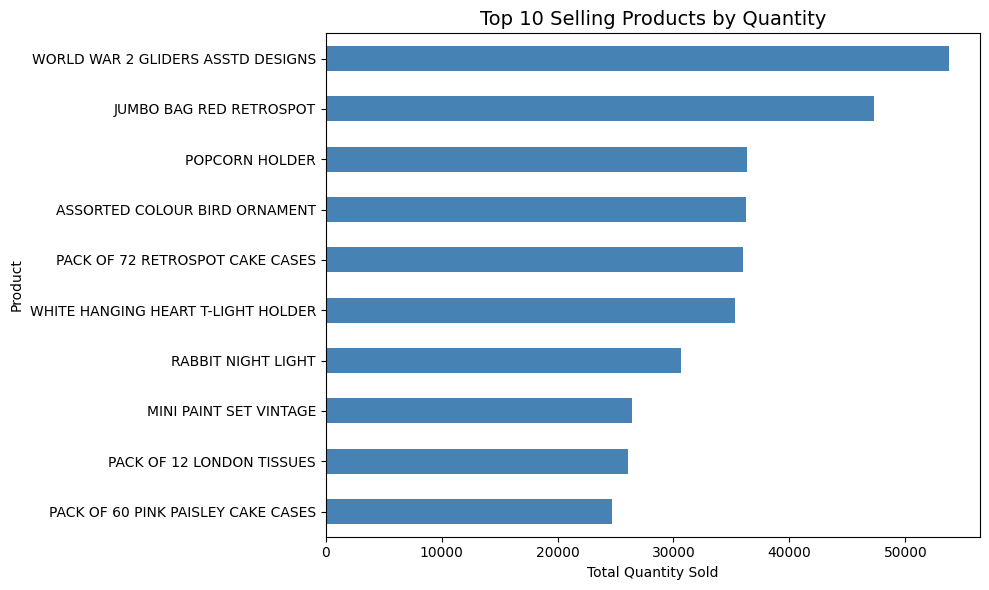

In [37]:
# Chart 1: Top 10 Selling Products by Quantity
plt.figure(figsize=(10,6))
top_products.plot(kind='barh', color='steelblue')
plt.title('Top 10 Selling Products by Quantity', fontsize=14)
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')
plt.gca().invert_yaxis()  # highest value at top
plt.tight_layout()
plt.show()

### Chart 1: Top 10 Selling Products by Quantity

**Title:** Top 10 Selling Products by Quantity
**X-axis:** Total Quantity Sold
**Y-axis:** Product

**Findings:** WORLD WAR 2 GLIDERS ASSTD DESIGNS is the clear top seller by volume, 
with over 53,000 units sold — noticeably ahead of the second-place product, 
JUMBO BAG RED RETROSPOT (~47,000 units). From third place onward (POPCORN HOLDER, 
ASSORTED COLOUR BIRD ORNAMENT, PACK OF 72 RETROSPOT CAKE CASES, WHITE HANGING HEART 
T-LIGHT HOLDER), quantities cluster much more closely together in the 35,000–36,000 
range, suggesting a more gradual drop-off rather than a single dominant product 
across the board. The top 10 is a mix of low-cost novelty items (gliders, night 
lights, paint sets) and party/craft supplies (cake cases, bags) — consistent with 
the retailer's overall gift/novelty product positioning we noted earlier.

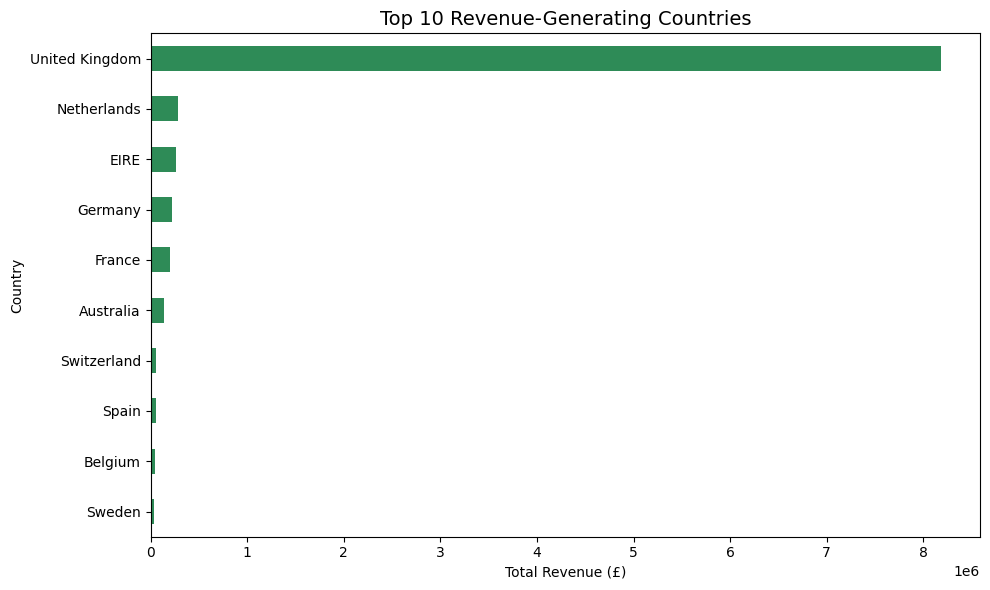

In [38]:
# Chart 2: Top 10 Revenue-Generating Countries
plt.figure(figsize=(10,6))
top_countries.plot(kind='barh', color='seagreen')
plt.title('Top 10 Revenue-Generating Countries', fontsize=14)
plt.xlabel('Total Revenue (£)')
plt.ylabel('Country')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Chart 2: Top 10 Revenue-Generating Countries

**Title:** Top 10 Revenue-Generating Countries
**X-axis:** Total Revenue (£)
**Y-axis:** Country

**Findings:** The United Kingdom overwhelmingly dominates total revenue at 
approximately £8.18M — so large that every other country appears almost flat by 
comparison on this scale, with the second-highest country (Netherlands, ~£285K) 
generating roughly 3.5% of the UK's revenue. This visually confirms what we found 
in EDA #2: the retailer's business is heavily concentrated domestically, with 
international sales spread thinly across a handful of nearby European markets 
(Netherlands, Ireland/EIRE, Germany, France) plus Australia. While this chart 
makes the UK's dominance clear, it isn't very useful for comparing the relative 
performance of the international markets against each other — a separate 
UK-excluded chart would be needed for that comparison.

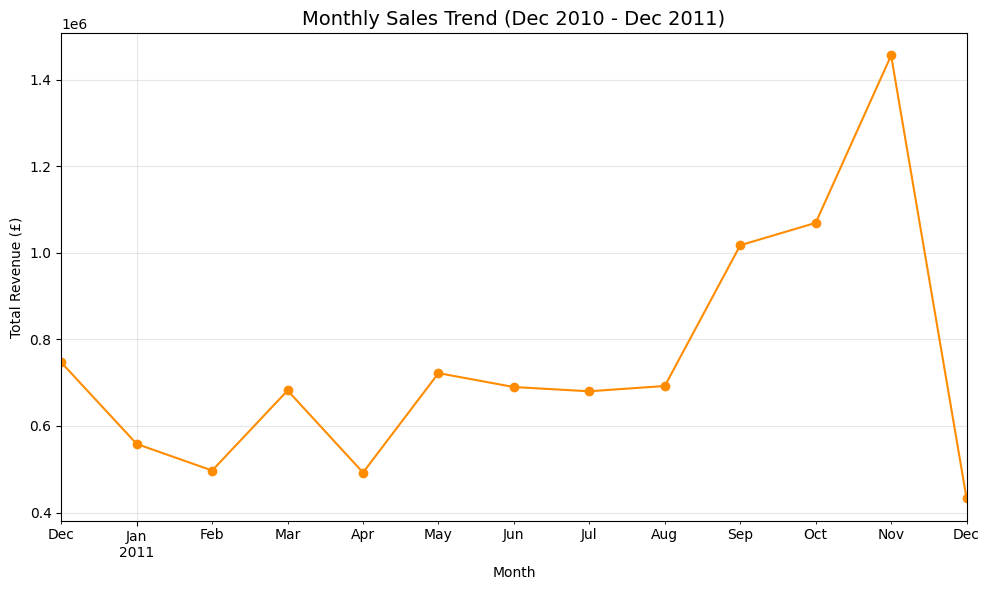

In [39]:
# Chart 3: Monthly Sales Trend
plt.figure(figsize=(10,6))
monthly_sales.plot(kind='line', marker='o', color='darkorange')
plt.title('Monthly Sales Trend (Dec 2010 - Dec 2011)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Revenue (£)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Chart 3: Monthly Sales Trend

**Title:** Monthly Sales Trend (Dec 2010 - Dec 2011)
**X-axis:** Month
**Y-axis:** Total Revenue (£)

**Findings:** Revenue stays relatively stable through the first three quarters, 
fluctuating between roughly £490K and £750K per month, with a modest early dip in 
Jan–Feb 2011 following the December 2010 start of the dataset. From September 2011 
onward, there's a clear and sustained upward climb, peaking sharply in November 
2011 at approximately £1.46M — nearly double the typical monthly revenue seen 
earlier in the year. This aligns with expected pre-Christmas seasonal buying, 
consistent with the retailer's gift/novelty product mix identified earlier.

**Important caveat:** The steep drop shown in December 2011 does **not** represent 
an actual decline in sales — the dataset's records end partway through that month, 
so this final point reflects only a partial month of data rather than a true 
month-over-month comparison. This should not be interpreted as a seasonal downturn.

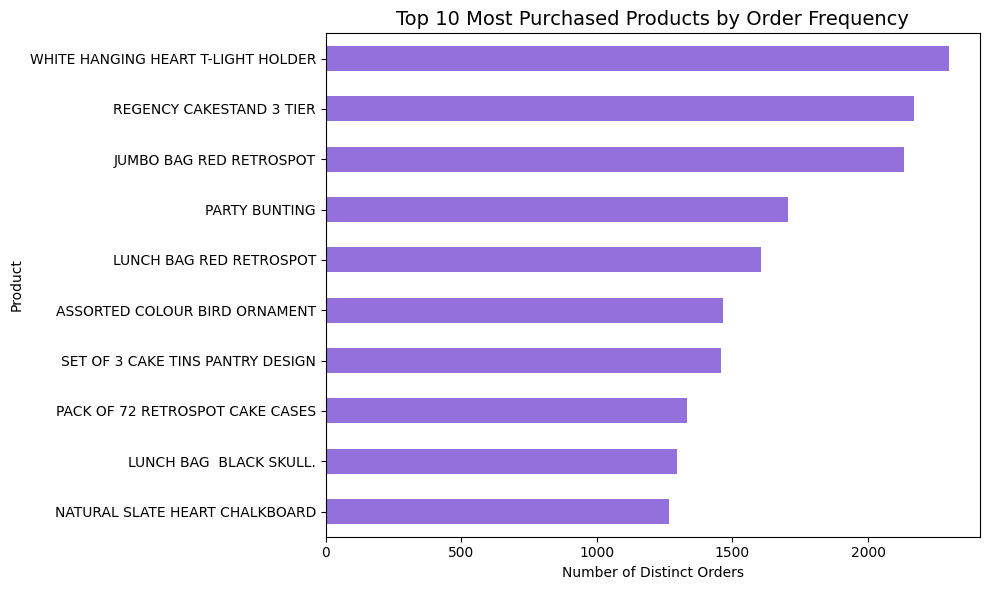

In [40]:
# Chart 4: Most Purchased Products by Order Frequency
plt.figure(figsize=(10,6))
most_purchased.plot(kind='barh', color='mediumpurple')
plt.title('Top 10 Most Purchased Products by Order Frequency', fontsize=14)
plt.xlabel('Number of Distinct Orders')
plt.ylabel('Product')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Chart 4: Most Purchased Products by Order Frequency

**Title:** Top 10 Most Purchased Products by Order Frequency
**X-axis:** Number of Distinct Orders
**Y-axis:** Product

**Findings:** WHITE HANGING HEART T-LIGHT HOLDER leads by order frequency, 
appearing in 2,298 distinct orders, closely followed by REGENCY CAKESTAND 3 TIER 
(2,169) and JUMBO BAG RED RETROSPOT (2,132). Comparing this to Chart 1 (top-selling 
by quantity) reveals a meaningful pattern: JUMBO BAG RED RETROSPOT, ASSORTED COLOUR 
BIRD ORNAMENT, and PACK OF 72 RETROSPOT CAKE CASES appear on **both** top-10 lists, 
indicating genuinely broad, consistent popularity — high volume *and* high 
frequency. In contrast, WHITE HANGING HEART T-LIGHT HOLDER and REGENCY CAKESTAND 
3 TIER top this frequency chart but were absent from the quantity chart, suggesting 
they're purchased by many different customers, just in smaller amounts each time — 
likely individual gift purchases rather than bulk buys. Notably, WORLD WAR 2 
GLIDERS ASSTD DESIGNS — the #1 product by total quantity sold — doesn't appear here 
at all, reinforcing that its high volume likely came from a small number of large 
bulk orders rather than widespread popularity across many customers.

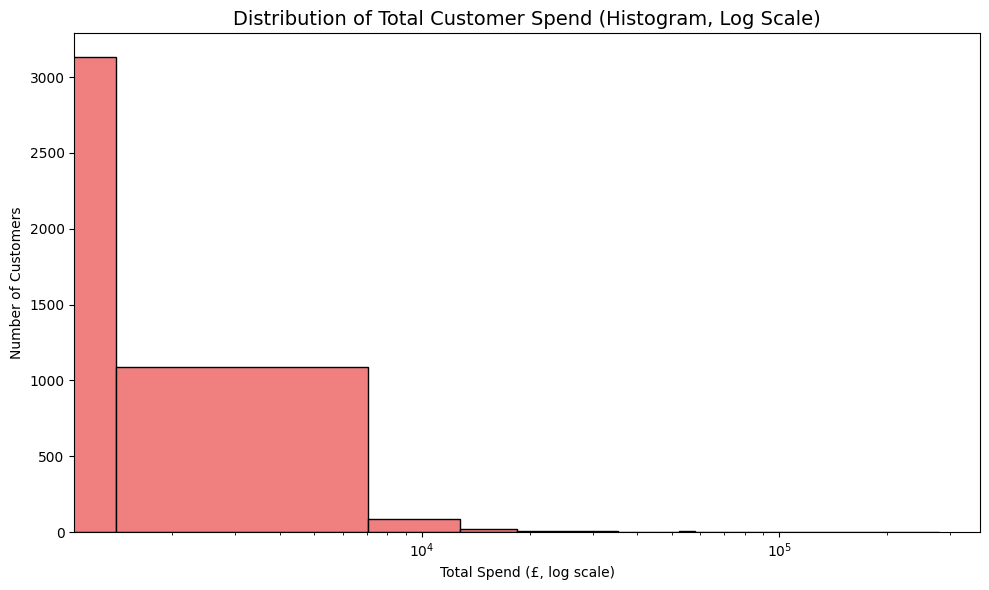

In [43]:
# Chart 5 (alternative): Histogram of Customer Spend (log-scaled x-axis)
plt.figure(figsize=(10,6))
plt.hist(customer_behavior['total_spend'], bins=50, color='lightcoral', edgecolor='black')
plt.xscale('log')
plt.title('Distribution of Total Customer Spend (Histogram, Log Scale)', fontsize=14)
plt.xlabel('Total Spend (£, log scale)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

### Chart 5: Distribution of Total Customer Spend

**Title:** Distribution of Total Customer Spend (Histogram, Log Scale)
**X-axis:** Total Spend (£, log scale)
**Y-axis:** Number of Customers

**Findings:** The vast majority of customers — over 3,000 — fall into the lowest 
spending bracket, followed by a second large group of roughly 1,100 customers in 
the next bracket up. From there, the number of customers drops off sharply as 
spend increases, with only a small handful of customers scattered out toward the 
£50,000–£280,000 range. This confirms what we found numerically in EDA #5: 
customer spending is heavily right-skewed, with most customers spending modestly 
and a small minority of high-value customers accounting for disproportionately 
large amounts. This kind of pattern is common in retail and is often the basis for 
identifying a "VIP" or high-value customer segment worth targeting with loyalty or 
retention efforts, since a small number of customers likely contribute a large 
share of total revenue.

## Task 5: Key Insights — E-commerce Dataset

### Insight 1: Sales are heavily seasonal, with a strong pre-Christmas surge

Monthly revenue stayed relatively stable through most of the year (roughly 
£490K–£750K per month), before climbing sharply from September 2011 onward and 
peaking at £1.46M in November 2011 — nearly double the typical monthly figure 
(*Chart 3: Monthly Sales Trend*). This pattern lines up closely with pre-Christmas 
gift-buying behavior, which is consistent with the retailer's product mix of 
inexpensive gifts, novelty items, and home decor (seen throughout *Chart 1* and 
*Chart 4*). 

**Business implication:** Inventory planning, staffing, and marketing spend 
should be weighted toward Q4, particularly September–November, to capture this 
seasonal demand. The apparent drop in December 2011 is a data artifact (the 
dataset ends mid-month) rather than a real decline, and should not be mistaken 
for a post-peak collapse.

---

### Insight 2: The business is overwhelmingly UK-domestic, with a thin international footprint

The United Kingdom generated approximately £8.18M in revenue — around 28 times 
more than the next-highest country, the Netherlands (£284,661) (*Chart 2: Top 10 
Revenue-Generating Countries*). The remaining top international markets (EIRE, 
Germany, France, Australia, and others) are all clustered at a much smaller scale, 
each contributing well under 5% of what the UK alone generates.

**Business implication:** This retailer's core business is domestic. If 
international growth is a strategic goal, the current customer base suggests 
nearby European markets (Netherlands, Ireland, Germany, France) are the most 
natural expansion targets, since some traction already exists there — rather than 
markets with negligible current presence.

---

### Insight 3: "Best-selling" products differ depending on how you define popularity

Comparing *Chart 1* (top products by total quantity sold) against *Chart 4* (top 
products by number of distinct orders) reveals two different customer behaviors. 
Products like JUMBO BAG RED RETROSPOT, ASSORTED COLOUR BIRD ORNAMENT, and PACK OF 
72 RETROSPOT CAKE CASES appear on **both** lists — indicating consistent, broad 
popularity in both volume and frequency. 

In contrast, WORLD WAR 2 GLIDERS ASSTD DESIGNS is the #1 product by total quantity 
(53,751 units) but doesn't appear in the top 10 by order frequency at all — 
meaning its volume is likely driven by a small number of large bulk orders rather 
than widespread customer demand. The opposite is true for WHITE HANGING HEART 
T-LIGHT HOLDER and REGENCY CAKESTAND 3 TIER, which top the order-frequency 
ranking but don't appear in the top quantity list — suggesting many different 
customers buy them, just in small amounts (likely single-item gift purchases).

**Business implication:** Inventory and marketing strategy should treat these 
product types differently — high-frequency, low-volume-per-order products are 
good candidates for broad marketing/gift bundling, while high-volume, low-frequency 
products may depend on a small number of wholesale or bulk-buying customers, 
representing more concentrated (and potentially fragile) revenue.

---

### Insight 4: A small number of high-value customers drive a disproportionate share of revenue

Customer spending is heavily right-skewed: the average customer spends £1,893.53, 
but the median is only £644.07 — meaning a small number of big spenders are 
pulling the average well above what a typical customer actually spends. This is 
visually confirmed in *Chart 5*, where the vast majority of customers cluster in 
the lowest spending bracket, while a handful of outliers extend out toward 
£280,000. 

The top single customer (ID 14646) spent £279,489 across 77 orders, while another 
customer (ID 14911) placed 248 orders — nearly triple the order count of any other 
top-10 customer — while spending less per order. This suggests at least two 
distinct high-value customer profiles: **large bulk buyers** (few orders, high 
spend per order) and **frequent repeat buyers** (many orders, moderate spend each 
time).

**Business implication:** This is a strong candidate for a customer segmentation 
or loyalty program. Identifying and retaining this small high-value segment (which 
likely represents a large share of total revenue, consistent with a classic 
80/20-style distribution) could be more impactful than broad, undifferentiated 
marketing to the full customer base, where the average customer places only about 
5 orders total.

---

### Insight 5: Returns and cancellations are a meaningful, traceable part of the business — not noise

During data validation and EDA, we found that negative quantities (returns/ 
cancellations) are common (9,725 rows) and, in the vast majority of cases (9,251), 
correctly tied to a cancelled invoice ("C" prefix) rather than representing data 
errors. Our deep-dive into the extreme outlier (80,995 units of PAPER CRAFT, 
LITTLE BIRDIE) showed a full order and its cancellation, placed by the same 
customer just 12 minutes apart — a legitimate, traceable business event, not a 
mistake.

**Business implication:** Returns/cancellations should be treated as a normal, 
expected part of this business's transaction data rather than excluded as 
"errors." Because our revenue and quantity figures throughout this analysis are 
net of returns (Chart 1, Chart 2, Chart 3 all reflect this), they represent a more 
accurate picture of true business performance than gross sales figures would. 
Future analysis could go further by specifically studying return *rates* by 
product or customer, to identify products with unusually high return activity — 
a natural next question this dataset could support.

In [44]:
# Save the cleaned dataset to CSV
df.to_csv('OnlineRetail_Cleaned.csv', index=False)

print("Cleaned dataset saved successfully!")
print(f"Final shape: {df.shape[0]} rows, {df.shape[1]} columns")

Cleaned dataset saved successfully!
Final shape: 534162 rows, 10 columns
